In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Step 4: Assemble the full EDA (statistics, univariate, outliers, bivariate, correlation) into one narrated 
notebook.

In [4]:
df = pd.read_csv("Iris.csv")

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [8]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


here we can see all the  descriptive statistics for this dataset, we can see the mean and the spread (std), also the quartiles (Q1, Q3) and median.

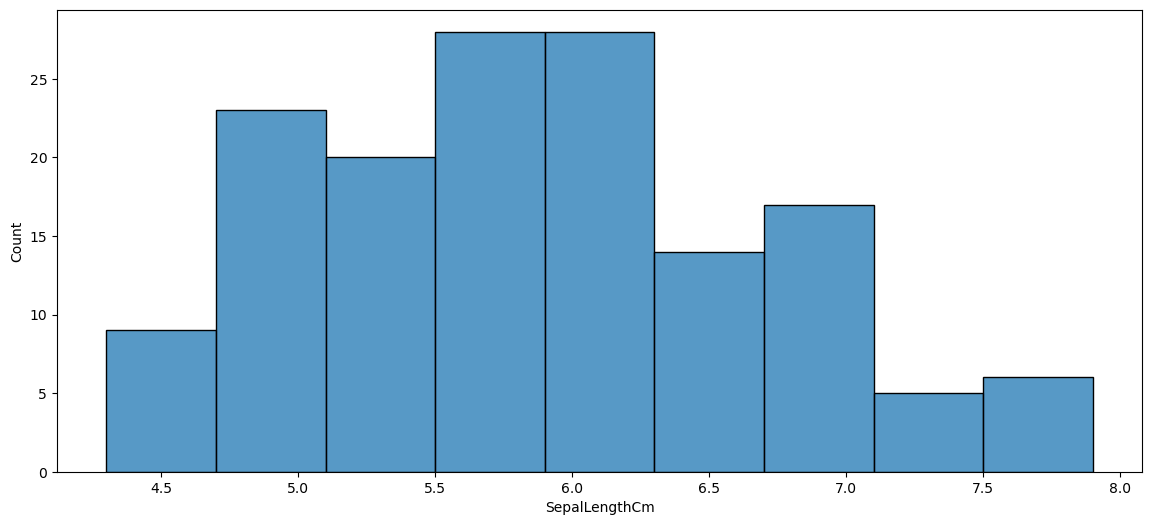

In [16]:
plt.figure(figsize=(14,6))
sns.histplot(data=df, x ="SepalLengthCm" )
plt.show()

we can see that this feature is normal and don't have any outliers. most of iris have a sepal length between 5.5-6.3sm.

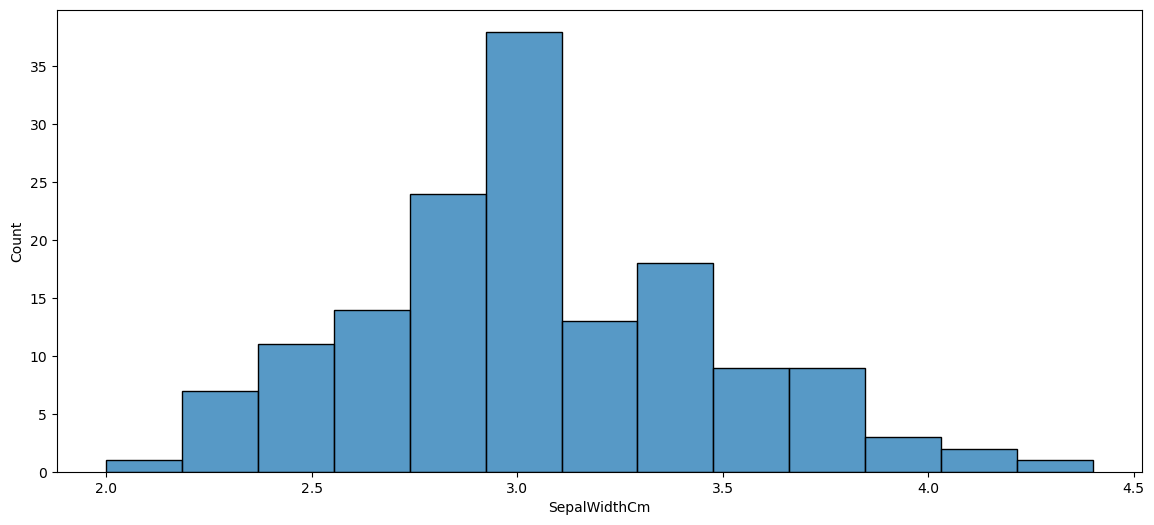

In [20]:
plt.figure(figsize=(14,6))
sns.histplot(data=df, x ="SepalWidthCm" )
plt.show()

most of irises have sepal width = ~3, and a minimum sepal width = 2 and ~4.3.

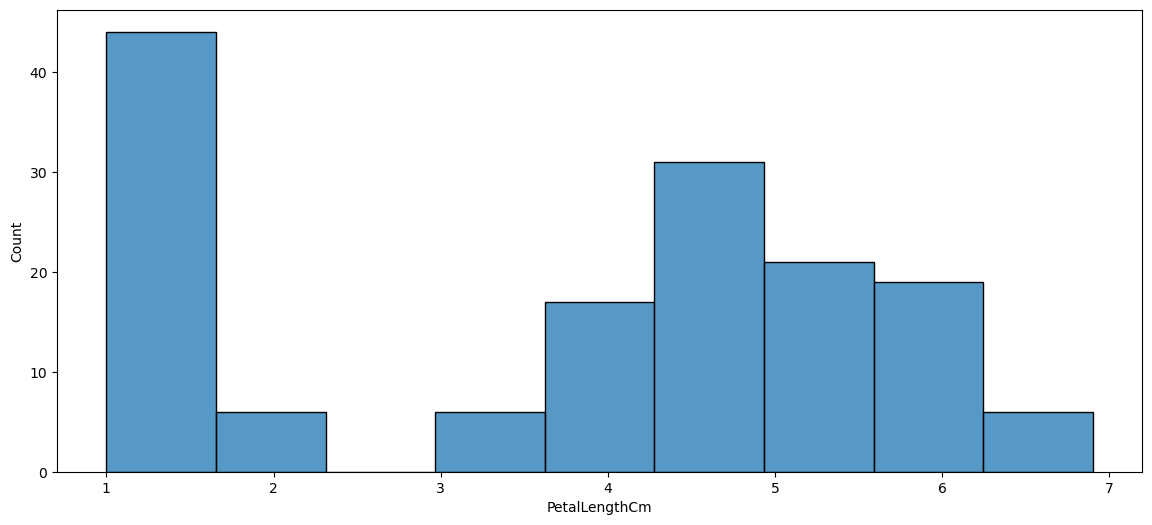

In [19]:
plt.figure(figsize=(14,6))
sns.histplot(data=df, x ="PetalLengthCm" )
plt.show()

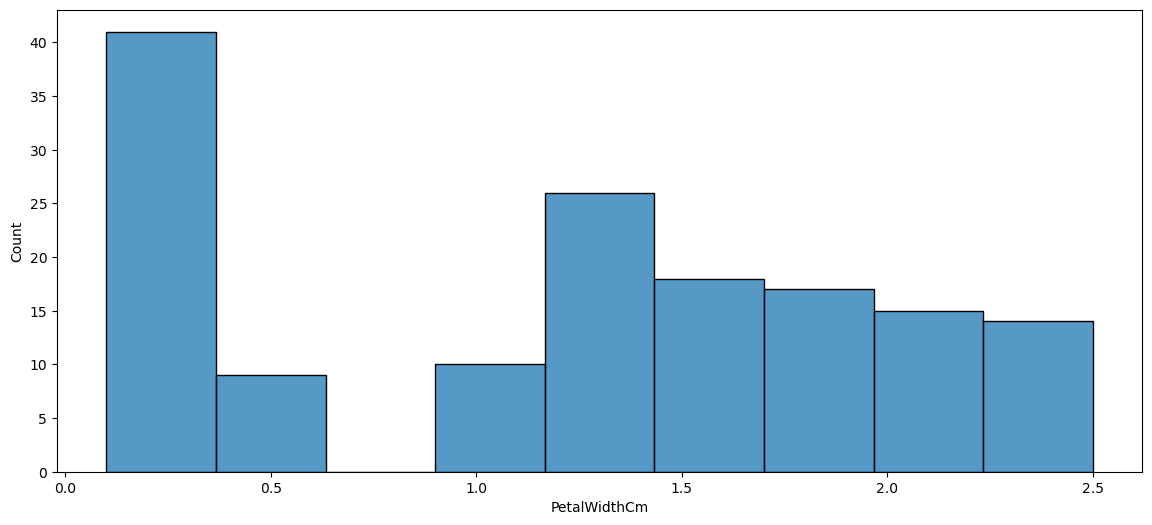

In [21]:
plt.figure(figsize=(14,6))
sns.histplot(data=df, x ="PetalWidthCm" )
plt.show()

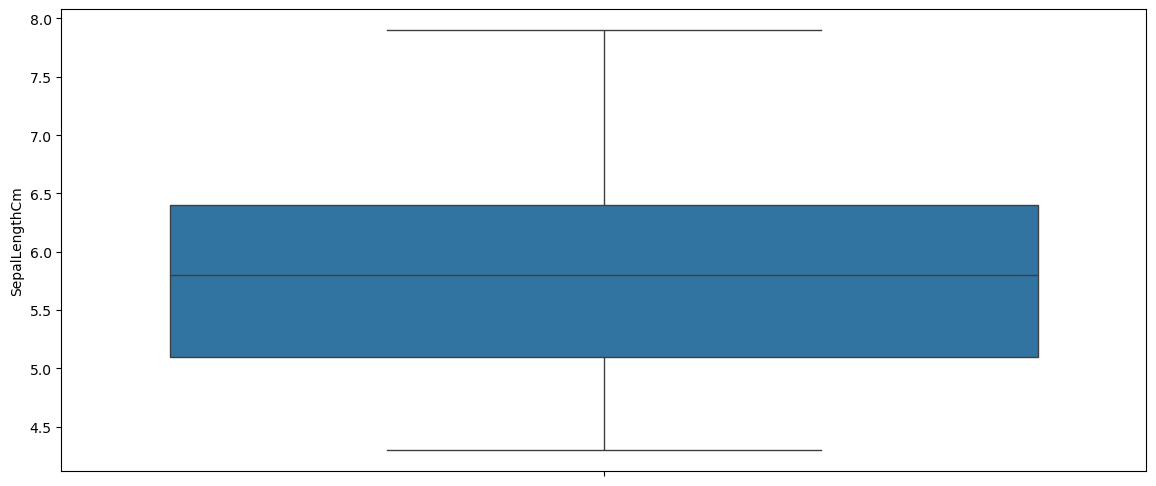

In [13]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df, y ="SepalLengthCm" )
plt.show()

here we can see that there is no outliers in sepal length. also we can see here that Q1 = ~5 median = ~5.5 Q3 = ~6.4.

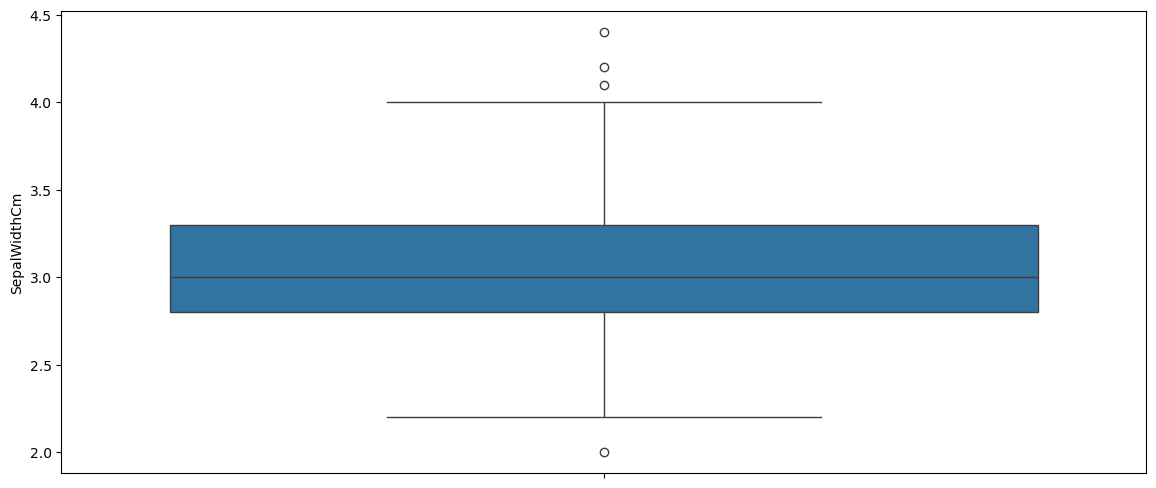

In [12]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df["SepalWidthCm"])
plt.show()

boxplot show that there is 4 outliers in sepal width.

In [14]:
Q1 = df["SepalWidthCm"].quantile(0.25)
Q3 = df["SepalWidthCm"].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df["SepalWidthCm"] < Q1 - 1.5*IQR) | (df["SepalWidthCm"] > Q3 + 1.5*IQR)]
outliers.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
15,16,5.7,4.4,1.5,0.4,Iris-setosa
32,33,5.2,4.1,1.5,0.1,Iris-setosa
33,34,5.5,4.2,1.4,0.2,Iris-setosa
60,61,5.0,2.0,3.5,1.0,Iris-versicolor


here is this 4 outliers from the boxplot. I will keep this outliers 'Cause it is not a fatal problem.

Step 1: Produce scatter plots and grouped box plots for the most important variable pairs in the dataset.

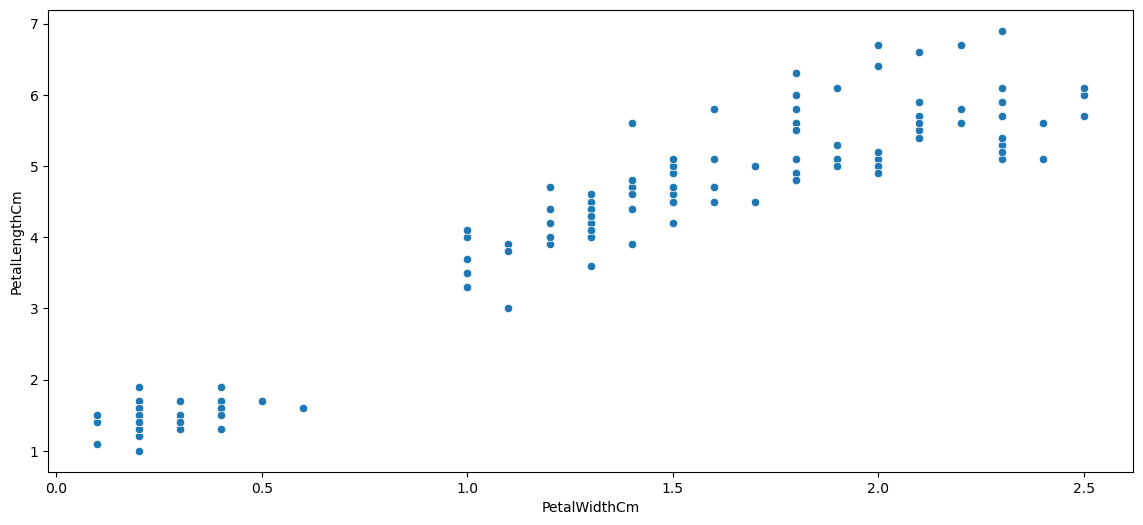

In [24]:
plt.figure(figsize=(14,6))
sns.scatterplot(data=df, x="PetalWidthCm", y ="PetalLengthCm")
plt.show()

here we have a positive relationship between petal width and petal length, when the petal width increase the petal length increase too.

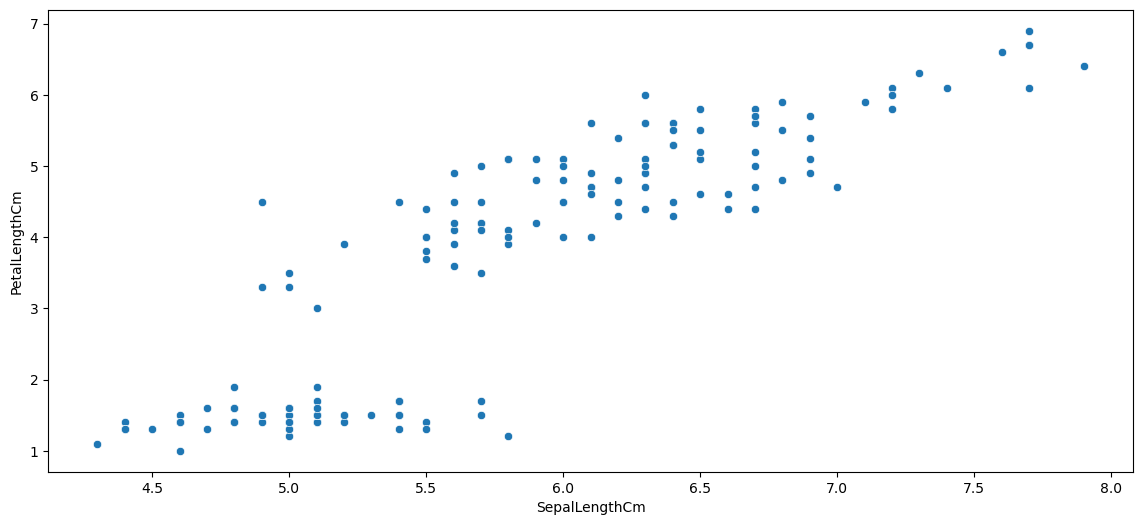

In [29]:
plt.figure(figsize=(14,6))
sns.scatterplot(data=df, x="SepalLengthCm", y ="PetalLengthCm")
plt.show()

here we also have positive relationship as we see above.

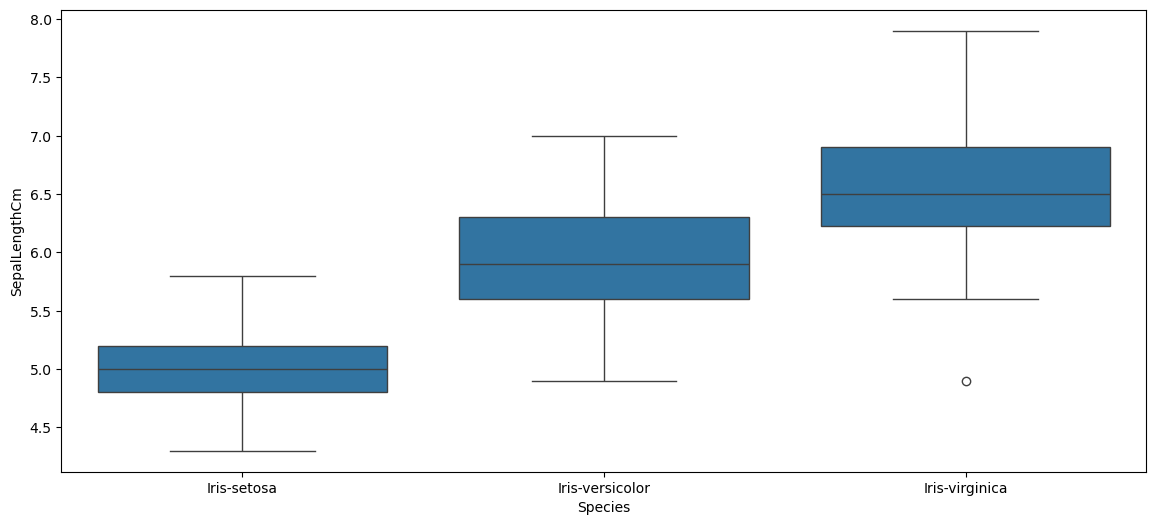

In [26]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df, x="Species", y ="SepalLengthCm")
plt.show()

the boxplot show us the relationship between species and sepal length. for example the seotos has the smallest length and virginica has the biggest sepal length. we can find out that the sepal length affect the species.

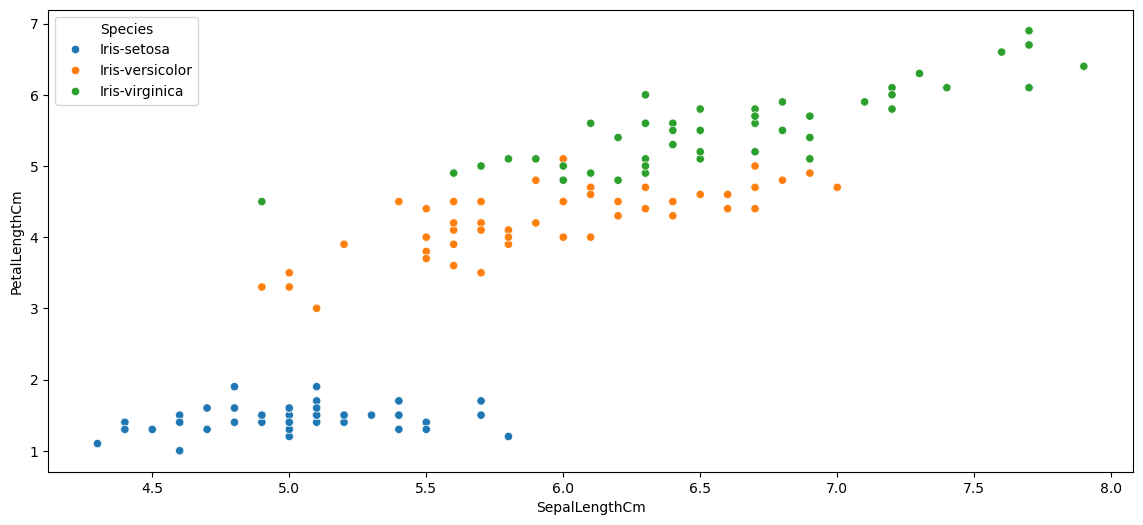

In [28]:
plt.figure(figsize=(14,6))
sns.scatterplot(data=df, x="SepalLengthCm", y ="PetalLengthCm", hue="Species")
plt.show()

here I combine 3 features together sepal and petal length with species. we can see that we have positive relationship between the two length, and also see how it affect the species.

Step 2: Compute the correlation matrix and visualize it as an annotated heatmap.

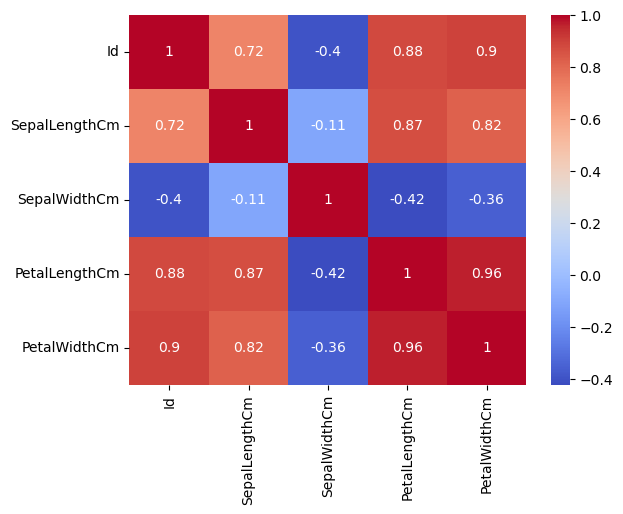

In [31]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

this heatmat show us all the relationships between all features, note that when the color is red there is a positive correlation, when it is blue a nigative correlation.

Step 3: Identify the two or three strongest relationships and state what they might mean for a future 
model.

the most strongest relationship is between petal length and petal width, it is = 0.96, this will allow the model make a good prediction since the model will recognize that when the petal length increase the petal width will increase too.
we also have a strong correlation between petal length and sepal length, it ia = 0.87. and between sepal length an petal width = 0.82.
note that we have a negative correlation between sepal length and sepal width = 0.11, it means that when the sepal length increase the sepal width decrease. but it is a weak correlation.